<a href="https://colab.research.google.com/github/mhizbulloh/UTS-Citra-Digital-2026-IF24a-Semester-4/blob/main/Jawaban_Nomor_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

👇 Silakan klik tombol 'Choose Files' di bawah untuk memilih gambar dari perangkat Anda:


Saving TranscodedWallpaper (1) to TranscodedWallpaper (1) (1)

✅ Memproses gambar: TranscodedWallpaper (1) (1)


/tmp/ipykernel_493/2916416563.py:30: RuntimeWarning: overflow encountered in scalar add
  c = 255 / np.log(1 + np.max(img))
/tmp/ipykernel_493/2916416563.py:30: RuntimeWarning: divide by zero encountered in log
  c = 255 / np.log(1 + np.max(img))
/tmp/ipykernel_493/2916416563.py:45: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[0, 1].hist(img.ravel(), 256, [0, 256], color='black')
/tmp/ipykernel_493/2916416563.py:51: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[1, 1].hist(img_negatif.ravel(), 256, [0, 256], color='black')
/tmp/ipykernel_493/2916416563.py:57: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axes[2, 1].hist

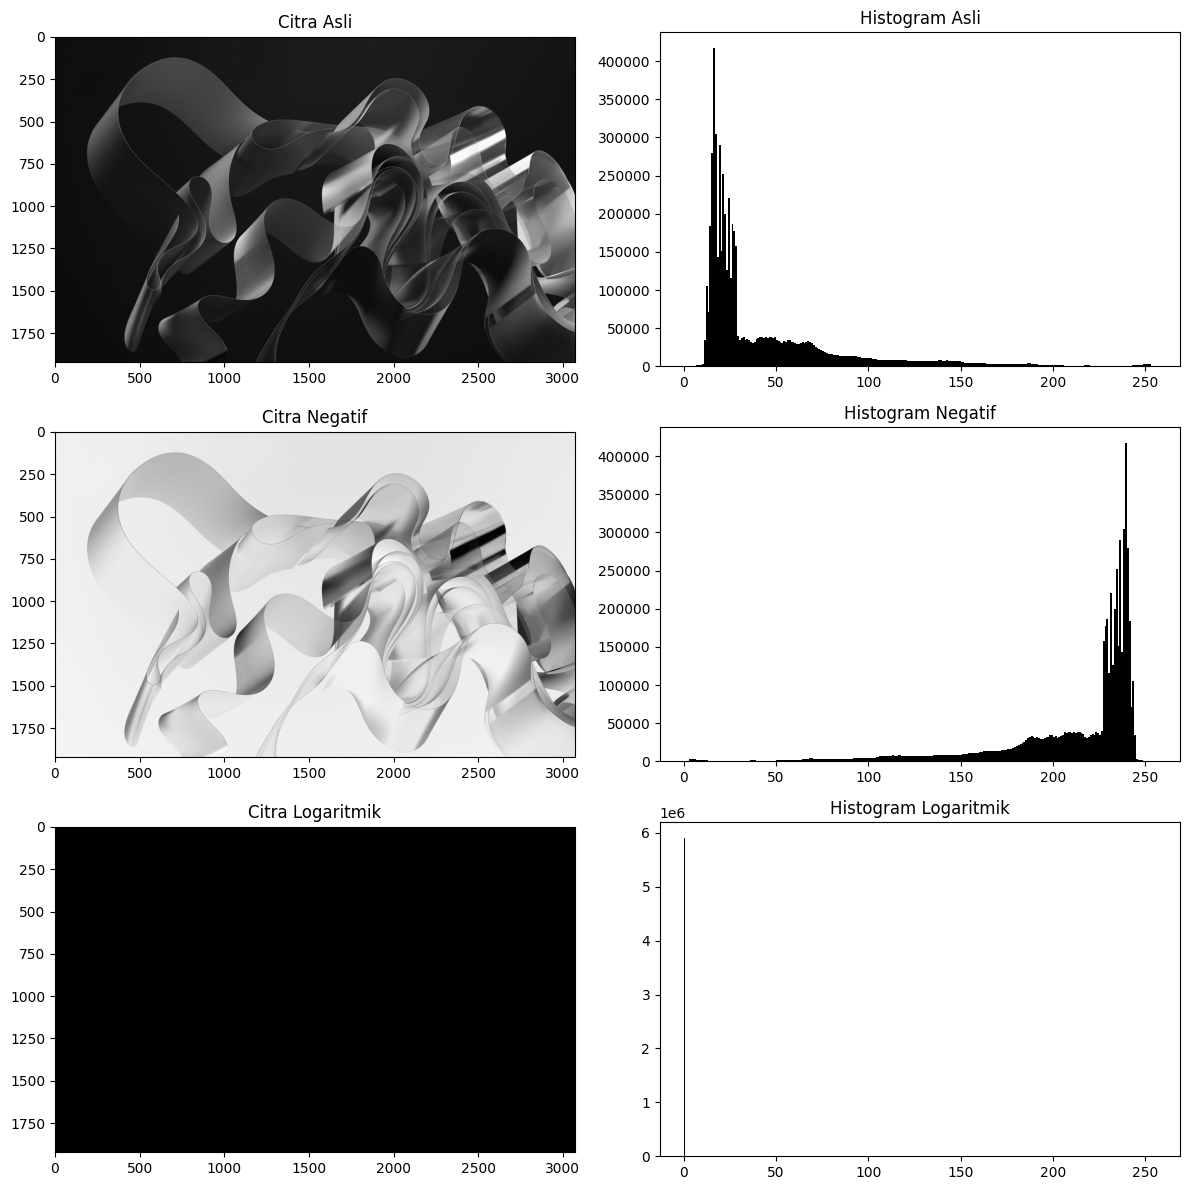


🎉 PROSES SOAL 1 SELESAI
1. Gambar dan Histogram telah berhasil ditampilkan.
2. File 'analisa.txt' telah berhasil dibuat dengan menyertakan nilai piksel dari foto Anda.
👉 Silakan buka menu folder (ikon 📁 di sebelah kiri Colab), lalu download 'analisa.txt' untuk di-upload ke GitHub.


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# --- Langkah 1: Meminta User Mengunggah Foto ---
print("👇 Silakan klik tombol 'Choose Files' di bawah untuk memilih gambar dari perangkat Anda:")
uploaded = files.upload()

# Mengecek apakah ada file yang diunggah
if not uploaded:
    print("❌ ERROR: Anda belum memilih gambar apapun.")
else:
    # Mengambil nama file gambar yang baru saja diunggah
    image_path = list(uploaded.keys())[0]
    print(f"\n✅ Memproses gambar: {image_path}")

    # --- Langkah 2: Baca Citra Grayscale ---
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        print("❌ ERROR: File yang diupload bukan gambar yang valid atau gagal dibaca.")
    else:
        # --- Langkah 3: Transformasi Negatif ---
        # Rumus: G = 255 - F
        img_negatif = 255 - img

        # --- Langkah 4: Transformasi Logaritmik ---
        # Rumus: G = c * log(1 + F)
        c = 255 / np.log(1 + np.max(img))
        img_log = c * np.log(1 + img.astype(np.float64))
        img_log = np.uint8(img_log)

        # --- Langkah 5: Menghitung Rata-rata Nilai Piksel (Untuk Analisis) ---
        mean_asli = np.mean(img)
        mean_negatif = np.mean(img_negatif)
        mean_log = np.mean(img_log)

        # --- Langkah 6: Tampilkan Gambar dan Histogram ---
        fig, axes = plt.subplots(3, 2, figsize=(12, 12))

        # Baris 1: Citra Asli
        axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
        axes[0, 0].set_title(f'Citra Asli')
        axes[0, 1].hist(img.ravel(), 256, [0, 256], color='black')
        axes[0, 1].set_title('Histogram Asli')

        # Baris 2: Citra Negatif
        axes[1, 0].imshow(img_negatif, cmap='gray', vmin=0, vmax=255)
        axes[1, 0].set_title('Citra Negatif')
        axes[1, 1].hist(img_negatif.ravel(), 256, [0, 256], color='black')
        axes[1, 1].set_title('Histogram Negatif')

        # Baris 3: Citra Logaritmik
        axes[2, 0].imshow(img_log, cmap='gray', vmin=0, vmax=255)
        axes[2, 0].set_title('Citra Logaritmik')
        axes[2, 1].hist(img_log.ravel(), 256, [0, 256], color='black')
        axes[2, 1].set_title('Histogram Logaritmik')

        plt.tight_layout()
        plt.show()

        # --- Langkah 7: Membuat file analisa.txt dengan Data Dinamis ---
        teks_analisa = f"""Analisa Transformasi Citra untuk file: {image_path}

1. Perbedaan persebaran nilai keabuan antara ketiga citra (Berdasarkan Hasil Eksekusi):
- Citra Asli: Berdasarkan histogram dari gambar yang diproses, nilai rata-rata intensitas pikselnya adalah {mean_asli:.2f}. Ini merepresentasikan distribusi keabuan natural dari citra input.
- Citra Negatif: Rata-rata intensitas piksel berubah menjadi {mean_negatif:.2f}. Pada histogram, terlihat bahwa grafiknya adalah cerminan/kebalikan sempurna dari histogram citra asli (dicerminkan di sumbu tengah). Piksel yang bernilai rendah (gelap) berpindah ke nilai tinggi (terang) secara persis.
- Citra Logaritmik: Rata-rata intensitas piksel bergeser menjadi {mean_log:.2f}. Pada histogram, terlihat pergeseran yang tidak linear. Piksel di area gelap ditarik/diregangkan menjauhi 0 sehingga menjadi lebih terang, sementara area terang dikompresi menjadi lebih sempit di area bernilai tinggi.

2. Kapan transformasi logaritmik lebih bermanfaat dibanding negatif?
Berdasarkan hasil pengamatan, transformasi logaritmik jauh lebih bermanfaat ketika kita perlu memperjelas detail yang tersembunyi pada area yang sangat gelap (underexposed), tanpa membuat area yang sudah terang menjadi rusak/terlalu putih. Ini sangat krusial pada citra astronomi atau rontgen medis.

Di sisi lain, transformasi negatif tidak cerdas dalam mengatur rentang dinamis karena ia hanya membalik semua warna. Transformasi negatif lebih bermanfaat hanya ketika kita butuh menonjolkan fitur terang di atas latar belakang luas yang berwarna hitam."""

        with open("analisa.txt", "w") as file:
            file.write(teks_analisa)

        print("\n🎉 PROSES SOAL 1 SELESAI")
        print("1. Gambar dan Histogram telah berhasil ditampilkan.")
        print("2. File 'analisa.txt' telah berhasil dibuat dengan menyertakan nilai piksel dari foto Anda.")
        print("👉 Silakan buka menu folder (ikon 📁 di sebelah kiri Colab), lalu download 'analisa.txt' untuk di-upload ke GitHub.")